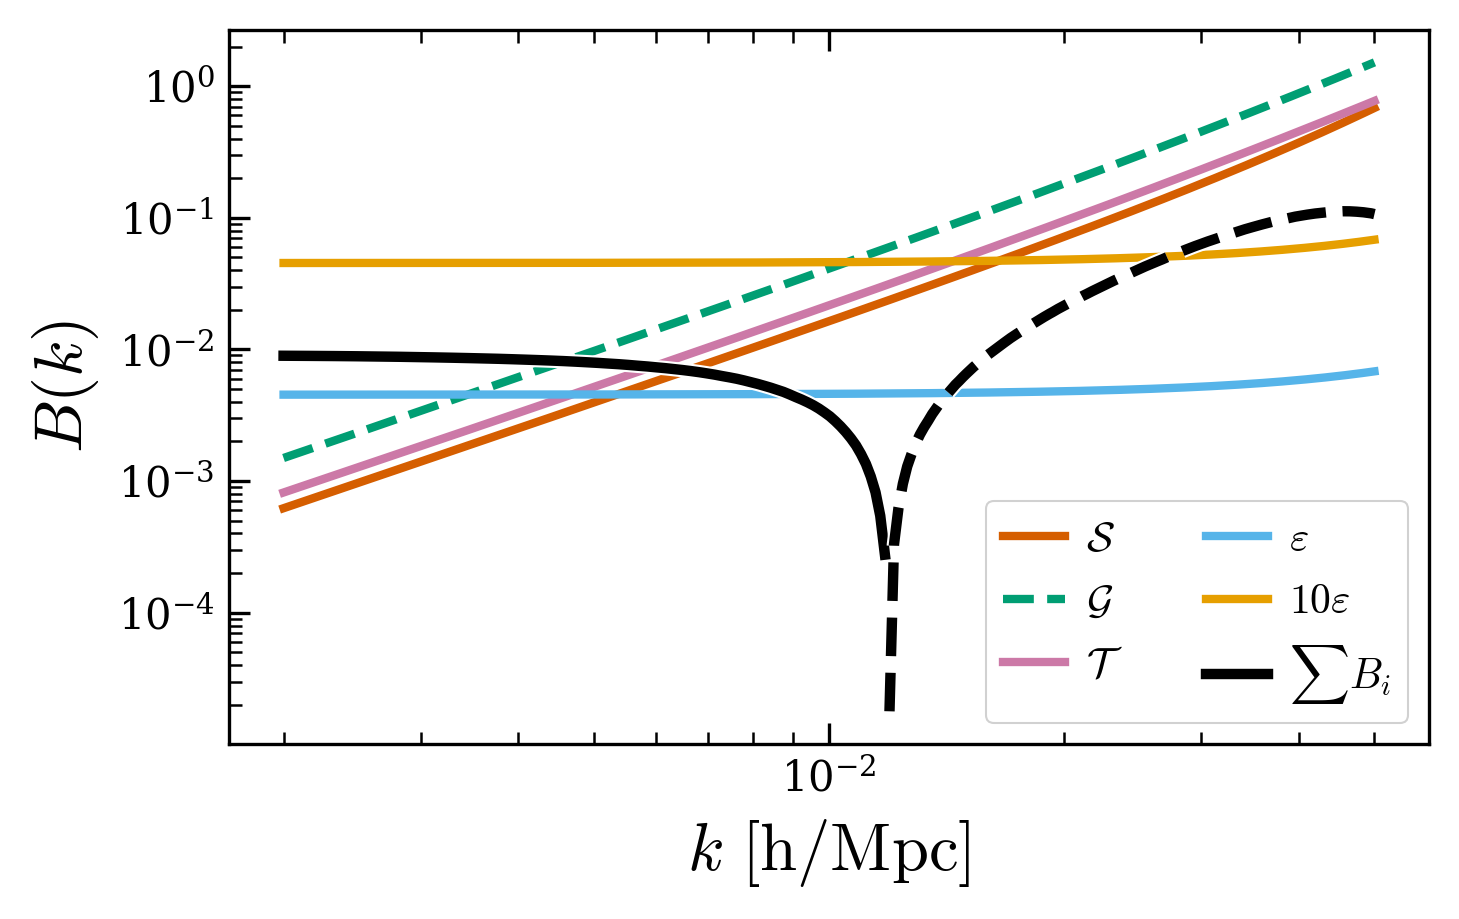

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl

# ---- CONFIGURATION ----
# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300

# Check for and configure LaTeX if available (optional but professional)
# Uncomment this if you have LaTeX installed
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

# If not using LaTeX, use a clean serif font
# Try to use TeX fonts that are included with matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})

# Define a modern, colorblind-friendly palette with higher contrast
# Based on colorblindness-friendly scientific palettes like viridis
# and ones recommended by Nature and Science publications
COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

# ---- DATA LOADING ----
out = np.load("out.npy", allow_pickle=True).item()
out_cross_shot = np.load("out_cross_shot.npy", allow_pickle=True).item()
Ks = out["Ks"]

epsilon = 1e-3
epsilon_2 = 10*epsilon

key_selected = "n"

# More descriptive and professionally formatted names
names = {
    "n": r"$\mathcal{D}$",          # Using calligraphic D for density
    "x": r"$\varepsilon$",           # Using proper epsilon symbol
    "s": r"$\mathcal{S}$",           # Calligraphic S
    "t": r"$\mathcal{T}$",           # Calligraphic T
    "g": r"$\mathcal{G}$",           # Calligraphic G
    "x2": r"$10\varepsilon$"         # 10 epsilon
}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
estimators_base = ["s", "g", "t", "x"]

normalization = out[(key_selected, key_selected)]**-1.
somma = 0
for e in estimators_base:
    try:
        somma += out[(key_selected, e)]*normalization
    except:
        somma += out[(e, key_selected)]*normalization

# Plot each keypair
keypairs_plot = [(key_selected, key_selected)] + [(key_selected, c) for c in estimators_all if c != key_selected]

derivatives = {}
epsilons = {"x": epsilon, "x2": epsilon_2}

# ---- FIGURE CREATION ----
# Create figure with golden ratio and higher dpi
fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')

# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

# Set up clean, professional plot styling with pure white background
ax.set_facecolor('white')
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
    spine.set_color('black')

# Professional tick parameters
ax.tick_params(axis='both', which='major', direction='in', length=5, width=0.8, 
               top=True, right=False, labelsize=10)
ax.tick_params(axis='both', which='minor', direction='in', length=3, width=0.6, 
               top=True, right=False)

# ---- DATA PLOTTING ----
# Keep track of lines for the legend
lines = []
labels = []
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 1))]  # Professional line styles

# Make sure we plot all the original labels
all_line_objects = []

for i, keypair in enumerate(keypairs_plot):
    keyA, keyB = keypair
    estimator_pair = f"{keyA}{keyB}"
    tr1 = "gal"
    tr2 = ""
    
    if estimator_pair in ["nn", f"{key_selected}{key_selected}"]:
        norm = out[keypair]**-1.
    
    # Get data values, handle key order
    try:
        value = out[keypair]*norm
    except:
        value = out[(keypair[1], keypair[0])]*norm
    
    # Sum components except for specific exclusions
    if estimator_pair not in ["nn", "nx2"]:
        somma += value
        
    # Calculate derivatives if needed
    if ("x" in estimator_pair) and (key_selected != "x"):
        derivatives[estimator_pair] = value/epsilons[keyB]

    plotting = False if "nn" in estimator_pair else True
    if not plotting:
        continue
    
    name = names[keyB]
    color = COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)]
    
    # Check if we have positive or negative values
    has_positive = np.any(value > 0)
    has_negative = np.any(value < 0)
    
    # Plot positive values with solid line
    if has_positive:
        l_pos = ax.loglog(Ks[value > 0], value[value > 0],
                         color=color,
                         linewidth=2,
                         linestyle=linestyles[0])
    
    # Plot negative values with dashed line
    if has_negative:
        l_neg = ax.loglog(Ks[value < 0], -value[value < 0],
                 color=color,
                 linewidth=2,
                 linestyle=linestyles[1])
    
    # Always add to legend, using the appropriate line object
    if has_positive:
        lines.append(l_pos[0])
    elif has_negative:
        lines.append(l_neg[0])
    else:
        # No data for this label, create dummy line for legend
        lines.append(mpl.lines.Line2D([], [], color=color, linestyle=linestyles[0]))
    
    # Always add the label
    labels.append(name)


# Plot the summed term (somma) in black with thicker line for emphasis
sign_changes = np.where(np.diff(np.signbit(somma)))[0]
if len(sign_changes) != 0:
    # Insert NaNs at sign changes to create breaks in the line
    Ks_plot = np.insert(Ks, sign_changes + 1, np.nan)
    value_plot = np.insert(somma, sign_changes + 1, np.nan)
else:
    Ks_plot = Ks
    value_plot = somma

# Separate positive and negative values
mask = value_plot >= 0
# Plot positive values with solid black line
if np.any(mask):
    l_sum_pos = ax.loglog(Ks_plot[mask], value_plot[mask], 
                        color='black', 
                        linewidth=2.5, 
                        linestyle='-',
                        path_effects=[patheffects.withStroke(linewidth=3.5, foreground='white')])
    lines.append(l_sum_pos[0])
    labels.append(r'$\sum B_i$')

# Plot negative values with dashed black line
mask = value_plot < 0
if np.any(mask):
    ax.loglog(Ks_plot[mask], -value_plot[mask], 
             color='black', 
             linewidth=2.5, 
             linestyle='--',
             path_effects=[patheffects.withStroke(linewidth=3.5, foreground='white')])

# ---- AXIS CONFIGURATION ----
# Set clean, professional labels
ax.set_xlabel(r'$k \ \mathrm{[h/Mpc]}$', fontsize=16)
ax.set_ylabel(r'$B(k)$', fontsize=16)

# Configure log scaling with appropriate minor ticks
ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))

# Remove ticks on the right y-axis
ax.tick_params(right=False)

# Set appropriate axis limits (adjust as needed)
# k_min, k_max = Ks.min() * 0.8, Ks.max() * 1.2
# ax.set_xlim(k_min, k_max)

# Remove grid lines for a clean white background
ax.grid(False)

# ---- LEGEND CONFIGURATION ----
# Create professional legend with all original labels
legend = ax.legend(lines, labels, 
                  ncol=2,  # 2 columns for better readability
                  frameon=True, 
                  framealpha=0.9,
                  edgecolor='#CCCCCC',
                  loc='best',  # Let matplotlib find the best location
                  fontsize=10,
                  handlelength=1.5,  # Shorter handles for compact legend
                  handletextpad=0.5)  # Less space between handle and text

# Set legend frame properties
legend.get_frame().set_linewidth(0.5)

# ---- SAVE FIGURE ----
# Save in both PDF (vector) and PNG (raster) formats
plt.savefig("../plots/bias.pdf", dpi=DPI, bbox_inches='tight')

plt.show()